# Method: Random Forest Wheat Segmentation

This method was inspired by the **EWS benchmark repository by Radek Zenkl and collaborators** https://github.com/RadekZenkl/EWS. It gave us a useful starting point for the overall idea of using a classical machine learning approach on the EWS wheat segmentation dataset. For our version, we built a simpler and more friendly baseline using handcrafted colour features and a **Random Forest** classifier to separate wheat from background. Tuning was built upon Chris Morris' baseline

## 1. Load and Prepare the Wheat Dataset

In [36]:
import os
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

plt.rcParams["figure.figsize"] = (10, 5)

In [37]:
# paths
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "EWS-Dataset"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"

print("train exists     :", TRAIN_DIR.exists())
print("validation exists:", VAL_DIR.exists())                                                             
print("test exists      :", TEST_DIR.exists())

train exists     : True
validation exists: True
test exists      : True


## Helper functions

- load images and masks
- build the handcrafted features
- train the model
- make predictions
- calculate the final results


In [38]:
def get_image_paths(split_dir):
    split_dir = Path(split_dir)
    all_pngs = sorted(split_dir.glob("*.png"))
    image_paths = [p for p in all_pngs if not p.name.endswith("_mask.png")]
    return image_paths


def get_mask_path(image_path):
    image_path = Path(image_path)
    return image_path.with_name(image_path.stem + "_mask.png")


def load_rgb_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"could not load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def load_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"could not load mask: {path}")
    mask = (mask > 127).astype(np.uint8)
    return mask


def rgb_to_hsi_features(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    intensity = (r + g + b) / 3.0
    min_rgb = np.minimum(np.minimum(r, g), b)

    saturation = np.zeros_like(intensity)
    valid = intensity > 1e-8
    saturation[valid] = 1.0 - (min_rgb[valid] / intensity[valid])

    num = 0.5 * ((r - g) + (r - b))
    den = np.sqrt((r - g) ** 2 + (r - b) * (g - b)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1.0, 1.0))

    hue = np.where(b <= g, theta, 2 * np.pi - theta)
    hue = hue / (2 * np.pi)

    return hue, saturation, intensity


def compute_pixel_features(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    hsv = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV).astype(np.float32)
    h_hsv = hsv[:, :, 0] / 179.0
    s_hsv = hsv[:, :, 1] / 255.0
    v_hsv = hsv[:, :, 2] / 255.0

    lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_lab = lab[:, :, 0] / 255.0
    a_lab = (lab[:, :, 1] - 128.0) / 127.0
    b_lab = (lab[:, :, 2] - 128.0) / 127.0

    ycrcb = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    y_ycc = ycrcb[:, :, 0] / 255.0
    cr_ycc = (ycrcb[:, :, 1] - 128.0) / 127.0
    cb_ycc = (ycrcb[:, :, 2] - 128.0) / 127.0

    h_hsi, s_hsi, i_hsi = rgb_to_hsi_features(rgb_img)

    exg = 2 * g - r - b
    ngrdi = (g - r) / (g + r + 1e-8)

    features = np.stack(
        [
            r, g, b,
            h_hsv, s_hsv, v_hsv,
            l_lab, a_lab, b_lab,
            y_ycc, cr_ycc, cb_ycc,
            h_hsi, s_hsi, i_hsi,
            exg, ngrdi,
        ],
        axis=-1,
    )

    h, w, c = features.shape
    return features.reshape(h * w, c)

## Check using 1 image

number of training images: 142
sample image: FPWW0220011_RGB1_20180316_100219_6.png
image shape : (350, 350, 3)
mask shape  : (350, 350)


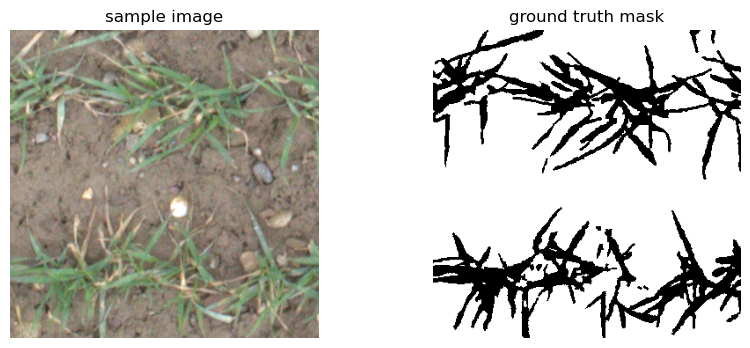

In [39]:
train_images = get_image_paths(TRAIN_DIR)
print("number of training images:", len(train_images))

sample_img_path = train_images[0]
sample_mask_path = get_mask_path(sample_img_path)

sample_img = load_rgb_image(sample_img_path)
sample_mask = load_mask(sample_mask_path)

print("sample image:", sample_img_path.name)
print("image shape :", sample_img.shape)
print("mask shape  :", sample_mask.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(sample_img)
ax[0].set_title("sample image")
ax[0].axis("off")

ax[1].imshow(sample_mask, cmap="gray")
ax[1].set_title("ground truth mask")
ax[1].axis("off")
plt.show()

## 2. Build the Features for the Model

In [40]:
def build_training_set(split_dir, pixels_per_image=4000, max_images=None, random_state=42):
    rng = np.random.default_rng(random_state)
    image_paths = get_image_paths(split_dir)

    if max_images is not None:
        image_paths = image_paths[:max_images]

    X_list = []
    y_list = []

    for image_path in image_paths:
        mask_path = get_mask_path(image_path)

        img = load_rgb_image(image_path)
        mask = load_mask(mask_path)

        X_img = compute_pixel_features(img)
        y_img = mask.reshape(-1)

        n_pixels = len(y_img)
        sample_n = min(pixels_per_image, n_pixels)
        idx = rng.choice(n_pixels, size=sample_n, replace=False)

        X_list.append(X_img[idx])
        y_list.append(y_img[idx])

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y


X_train, y_train = build_training_set(
    TRAIN_DIR,
    pixels_per_image=4000,   # safe starting point
    max_images=None,         # use all training images
    random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("plant pixels:", int(y_train.sum()))
print("soil pixels :", int((y_train == 0).sum()))


X_train shape: (568000, 17)
y_train shape: (568000,)
plant pixels: 449006
soil pixels : 118994


## 3. Train the Random Forest Model

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

start_train = time.time()

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train_scaled, y_train)

train_time = time.time() - start_train
print(f"training finished in {train_time:.2f} seconds")


training finished in 29.87 seconds


## Prediction and evaluation helpers

In [41]:
def predict_mask(model, scaler, rgb_img):
    X = compute_pixel_features(rgb_img)
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)
    return pred.reshape(rgb_img.shape[:2]).astype(np.uint8)


def evaluate_split(split_dir, model, scaler, max_images=None):
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    image_metrics = []
    predictions = []
    ground_truths = []
    image_names = []

    start_test = time.time()

    for image_path in image_paths:
        mask_path = get_mask_path(image_path)

        img = load_rgb_image(image_path)
        gt = load_mask(mask_path)
        pred = predict_mask(model, scaler, img)

        precision = precision_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        recall = recall_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        f1 = f1_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        iou = jaccard_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)

        image_metrics.append([precision, recall, f1, iou])
        predictions.append(pred)
        ground_truths.append(gt)
        image_names.append(image_path.name)

    test_time = time.time() - start_test

    image_metrics = np.array(image_metrics)
    summary = {
        "precision": float(image_metrics[:, 0].mean()),
        "recall": float(image_metrics[:, 1].mean()),
        "f1": float(image_metrics[:, 2].mean()),
        "iou": float(image_metrics[:, 3].mean()),
        "time_seconds": float(test_time),
        "num_images": len(image_paths),
    }

    return summary, image_names, predictions, ground_truths


## Validate on the validation split

Tune on validation first. Save the test split for final evaluation.

In [42]:
val_summary, val_names, val_preds, val_gts = evaluate_split(VAL_DIR, rf, scaler)

print("validation summary")
for k, v in val_summary.items():
    print(f"{k:>12}: {v:.4f}" if isinstance(v, float) else f"{k:>12}: {v}")


validation summary
   precision: 0.9260
      recall: 0.8869
          f1: 0.9024
         iou: 0.8313
time_seconds: 6.9208
  num_images: 24


## Final evaluation on the test split

In [44]:
# Final eval
test_summary, test_names, test_preds, test_gts = evaluate_split_v2(TEST_DIR, rf_v2, scaler_v2)

print("test summary")
for k, v in test_summary.items():
    print(f"{k:>12}: {v:.4f}" if isinstance(v, float) else f"{k:>12}: {v}")


test summary
   precision: 0.9457
      recall: 0.9216
          f1: 0.9321
         iou: 0.8764
time_seconds: 12.2925
  num_images: 24


## Visualise some results

In [11]:
def show_result(split_names, preds, gts, split_dir, idx=0):
    image_path = Path(split_dir) / split_names[idx]
    img = load_rgb_image(image_path)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(img)
    ax[0].set_title("image")
    ax[0].axis("off")

    ax[1].imshow(gts[idx], cmap="gray")
    ax[1].set_title("ground truth")
    ax[1].axis("off")

    ax[2].imshow(preds[idx], cmap="gray")
    ax[2].set_title("prediction")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


show_result(test_names, test_preds, test_gts, TEST_DIR, idx=0)


NameError: name 'test_names' is not defined

## 4. Experiment Utils
Helper for automating the logging of evaluation results. Appends a single run's results to the excel file in the same dir.

In [15]:
import openpyxl
from datetime import datetime

XLSX_PATH = Path("training_results_history.xlsx")

def log_run(xlsx_path, run_name, model, hparams, precision, recall, f1, iou, train_time_s, eval_time_s, notes=""):
    wb = openpyxl.load_workbook(xlsx_path)
    ws = wb.active

    hparams_str = (                               
        ", ".join(f"{k}={v}" for k, v in hparams.items())
        if isinstance(hparams, dict) else str(hparams)                                                    
    )       

    ws.append([
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),                                                     
        run_name,
        model,
        hparams_str,
        round(float(precision), 4),
        round(float(recall), 4),
        round(float(f1), 4),
        round(float(iou), 4),
        round(float(train_time_s), 2),
        round(float(eval_time_s), 2),
        notes
    ])
    wb.save(xlsx_path)
    print(f"logged: {run_name}")

## 5. Experiment 1 - Hyperparameter sweep

In [16]:
configs = [
    dict(n_estimators=n, max_depth=d, min_samples_leaf=msl, class_weight="balanced_subsample")
    for n in [100, 200, 400]
    for d in [None, 20, 40]
    for msl in [1, 4]
]

print(f"total configs: {len(configs)}\n")

for i, cfg in enumerate(configs, 1):
    print(f"[{i}/{len(configs)}] {cfg}")

    start = time.time()
    rf_cfg = RandomForestClassifier(
        **cfg,
        n_jobs=-1,
        random_state=42,
        oob_score=True,
    )
    rf_cfg.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    val_summary, _, _, _ = evaluate_split(VAL_DIR, rf_cfg, scaler)

    run_name = f"sweep_n{cfg['n_estimators']}_d{cfg['max_depth']}_msl{cfg['min_samples_leaf']}"
    log_run(
        XLSX_PATH,
        run_name=run_name,
        model="RandomForest",
        hparams=cfg,
        precision=val_summary["precision"],
        recall=val_summary["recall"],
        f1=val_summary["f1"],
        iou=val_summary["iou"],
        train_time_s=train_time,
        eval_time_s=val_summary["time_seconds"],
        notes=f"val split, oob={rf_cfg.oob_score_:.4f}",
    )

    print(f"  train={train_time:.1f}s  val F1={val_summary['f1']:.4f}  OOB acc={rf_cfg.oob_score_:.4f}\n")

print("Sweep Complete")



total configs: 18

[1/18] {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
logged: sweep_n100_dNone_msl1
  train=44.7s  val F1=0.8936  OOB acc=0.9078

[2/18] {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}
logged: sweep_n100_dNone_msl4
  train=42.0s  val F1=0.9022  OOB acc=0.9170

[3/18] {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
logged: sweep_n100_d20_msl1
  train=42.6s  val F1=0.9025  OOB acc=0.9185

[4/18] {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 4, 'class_weight': 'balanced_subsample'}
logged: sweep_n100_d20_msl4
  train=34.4s  val F1=0.9022  OOB acc=0.9180

[5/18] {'n_estimators': 100, 'max_depth': 40, 'min_samples_leaf': 1, 'class_weight': 'balanced_subsample'}
logged: sweep_n100_d40_msl1
  train=43.5s  val F1=0.8937  OOB acc=0.9082

[6/18] {'n_estimators': 100, 'max_depth': 40, 'min_samples_leaf': 4,

## Experiment 2 - Multi-scale Gaussian features

In [22]:
def compute_multiscale_features(rgb_img, sigmas=(1, 2, 4, 8)):
    rgb = rgb_img.astype(np.float32) / 255.0
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]

    lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB).astype(np.float32)
    a_lab = (lab[:, :, 1] - 128.0) / 127.0
    
    exg = 2 * g - r - b
    ngrdi = (g - r) / (g + r + 1e-8)

    channels = [a_lab, exg, ngrdi]
    features_list = []
    for channel in channels:
        for sigma in sigmas:
            blurred = cv2.GaussianBlur(channel, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
            features_list.append(blurred)

    features = np.stack(features_list, axis=-1)
    h, w, c = features.shape
    return features.reshape(h * w, c)

def compute_pixel_features_v2(rgb_img):
    base = compute_pixel_features(rgb_img)
    ms = compute_multiscale_features(rgb_img)
    return np.hstack([base, ms])

def build_training_set_v2(split_dir, pixels_per_image=4000, max_images=None, random_state=42):
    rng = np.random.default_rng(random_state)
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    x_list, y_list = [], []
    for image_path in image_paths:
        img = load_rgb_image(image_path)
        mask = load_mask(get_mask_path(image_path))
        
        x_img = compute_pixel_features_v2(img)
        y_img = mask.reshape(-1)

        n = min(pixels_per_image, len(y_img))
        idx = rng.choice(len(y_img), size=n, replace=False)
        
        x_list.append(x_img[idx])
        y_list.append(y_img[idx])

    return np.vstack(x_list), np.concatenate(y_list)

def predict_mask_v2(model, scaler, rgb_img):
    x = compute_pixel_features_v2(rgb_img)
    x_scaled = scaler.transform(x)
    pred = model.predict(x_scaled)
    return pred.reshape(rgb_img.shape[:2]).astype(np.uint8)

def evaluate_split_v2(split_dir, model, scaler, max_images=None):
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    image_metrics, predictions, ground_truths, image_names = [], [], [], []
    start = time.time()
    for image_path in image_paths:
        img = load_rgb_image(image_path)
        gt = load_mask(get_mask_path(image_path))
        pred = predict_mask_v2(model, scaler, img)

        image_metrics.append([
            precision_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            recall_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            f1_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            jaccard_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
        ])
        predictions.append(pred)
        ground_truths.append(gt)
        image_names.append(image_path.name)
    test_time = time.time() - start

    image_metrics = np.array(image_metrics)
    return {
        "precision": float(image_metrics[:, 0].mean()),
        "recall": float(image_metrics[:, 1].mean()),
        "f1": float(image_metrics[:, 2].mean()),
        "iou": float(image_metrics[:, 3].mean()),
        "time_seconds": float(test_time),
        "num_images": len(image_paths),
    }, image_names, predictions, ground_truths

In [23]:
# Build v2 training set
x_train_v2, y_train_v2 = build_training_set_v2(
    TRAIN_DIR, pixels_per_image=4000, random_state=42
)
print(f"x_train_v2 shape: {x_train_v2.shape}")
print(f"plant pixels: {int(y_train_v2.sum())}")
print(f"soil pixels: {int((y_train_v2 == 0).sum())}")

# Fit scaler on v2 features
scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(x_train_v2)

# Train RF with plateau hparams from experiment 1
start = time.time()

rf_v2 = RandomForestClassifier(
  n_estimators=200,
  max_depth=20,
  min_samples_leaf=1,
  class_weight="balanced_subsample",
  n_jobs=-1,
  random_state=42,
  oob_score=True,
)
rf_v2.fit(X_train_v2_scaled, y_train_v2)

train_time_v2 = time.time() - start
print(f"training finished in {train_time_v2:.2f} seconds (OOB={rf_v2.oob_score_:.4f})")

# Evaluate on val
val_v2_summary, val_v2_names, val_v2_preds, val_v2_gts = evaluate_split_v2(VAL_DIR, rf_v2, scaler_v2)

print("\nvalidation summary (multi-scale)")
for k, v in val_v2_summary.items():
  print(f"  {k:>12}: {v:.4f}" if isinstance(v, float) else f"  {k:>12}: {v}")

log_run(                                                                                                  
  XLSX_PATH,                                    
  run_name="multiscale_sigma1248_3ch",          
  model="RandomForest",                                                                                 
  hparams={                                               
      "n_estimators": 200,                                                                              
      "max_depth": 20,                                    
      "min_samples_leaf": 1,                                                                            
      "class_weight": "balanced_subsample",     
      "features": "17colour+12multiscale(a_lab,ExG,NGRDI @ sigma=1,2,4,8)",                             
  },                                            
  precision=val_v2_summary["precision"],                                                                
  recall=val_v2_summary["recall"],                                                                      
  f1=val_v2_summary["f1"],                                                                              
  iou=val_v2_summary["iou"],                                                                            
  train_time_s=train_time_v2,                                                                           
  eval_time_s=val_v2_summary["time_seconds"],   
  notes=f"val split; oob={rf_v2.oob_score_:.4f}; experiment 2 — multi-scale features",
)

x_train_v2 shape: (568000, 29)
plant pixels: 449006
soil pixels: 118994
training finished in 262.25 seconds (OOB=0.9456)

validation summary (multi-scale)
     precision: 0.9474
        recall: 0.9227
            f1: 0.9331
           iou: 0.8798
  time_seconds: 39.6179
    num_images: 24
logged: multiscale_sigma1248_3ch


## Experiment 3 - Feature Ablation and Importance

In [30]:
def compute_pixel_features_v3(rgb_img, channel_name):
    base = compute_pixel_features(rgb_img)

    rgb = rgb_img.astype(np.float32) / 255.0
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]

    if channel_name == "a_lab":
        lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB).astype(np.float32)
        ch = (lab[:, :, 1] - 128.0) / 127.0
    elif channel_name == "exg":
        ch = 2 * g - r - b
    elif channel_name == "ngrdi":
        ch = (g - r) / (g + r + 1e-8)
    else:
        raise ValueError(f"unknown channel: {channel_name}")

    ms = np.stack(
        [cv2.GaussianBlur(ch, (0, 0), sigmaX=s, sigmaY=s) for s in (1, 2, 4, 8)],
        axis=-1,
    )
    h, w, _ = ms.shape
    return np.hstack([base, ms.reshape(h* w, -1)])

def build_training_set_v3(split_dir, channel_name, pixels_per_image=4000, max_images=None, random_state=42):
    rng = np.random.default_rng(random_state)
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    x_list, y_list = [], []
    for image_path in image_paths:
        img = load_rgb_image(image_path)
        mask = load_mask(get_mask_path(image_path))

        x_img = compute_pixel_features_v3(img, channel_name)
        y_img = mask.reshape(-1)

        n = min(pixels_per_image, len(y_img))
        idx = rng.choice(len(y_img), size=n, replace=False)

        x_list.append(x_img[idx])
        y_list.append(y_img[idx])
    
    return np.vstack(x_list), np.concatenate(y_list)

def evaluate_split_v3(split_dir, model, scaler, channel_name, max_images=None):
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    image_metrics, predictions, ground_truths, image_names = [], [], [], []

    start = time.time()
    for image_path in image_paths:
        img = load_rgb_image(image_path)
        gt = load_mask(get_mask_path(image_path))

        x = compute_pixel_features_v3(img, channel_name)
        x_scaled = scaler.transform(x)
        pred = model.predict(x_scaled).reshape(img.shape[:2]).astype(np.uint8)

        image_metrics.append([
            precision_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            recall_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            f1_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
            jaccard_score(gt.reshape(-1), pred.reshape(-1), zero_division=0),
        ])

        predictions.append(pred)
        ground_truths.append(gt)
        image_names.append(image_path.name)
    test_time = time.time() - start

    image_metrics = np.array(image_metrics)
    return {
        "precision": float(image_metrics[:, 0].mean()),
        "recall": float(image_metrics[:, 1].mean()),
        "f1": float(image_metrics[:, 2].mean()),
        "iou": float(image_metrics[:, 3].mean()),
        "time_seconds": float(test_time),
        "num_images": len(image_paths),
    }, image_names, predictions, ground_truths

In [31]:
ablation_channels = ["a_lab", "exg", "ngrdi"]

for channel_name in ablation_channels:
    print(f"\n=== ablation: colour + multi-scale({channel_name}) ===")

    x_train_abl, y_train_abl = build_training_set_v3(
        TRAIN_DIR, channel_name, pixels_per_image=4000, random_state=42
    )
    print(f"x_train_abl shape: {x_train_abl.shape}")

    scaler_abl = StandardScaler()
    x_train_abl_scaled = scaler_abl.fit_transform(x_train_abl)

    start_train = time.time()
    rf_abl = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
        oob_score=True,
    )
    rf_abl.fit(x_train_abl_scaled, y_train_abl)
    train_time_abl = time.time() - start_train
    print(f"training finished in {train_time_abl:.2f} seconds (OOB={rf_abl.oob_score_:.4f})")

    val_abl_summary, _, _, _ = evaluate_split_v3(VAL_DIR, rf_abl, scaler_abl, channel_name)
    print(f"val F1={val_abl_summary['f1']:.4f}  P={val_abl_summary['precision']:.4f} R={val_abl_summary['recall']:.4f}  IoU={val_abl_summary['iou']:.4f}")

    log_run(
        XLSX_PATH,
        run_name=f"ablation_multiscale_{channel_name}_only",
        model="RandomForest",
        hparams={
            "n_estimators": 200,
            "max_depth": 20,
            "min_samples_leaf": 1,
            "class_weight": "balanced_subsample",
            "features": f"17colour+4multiscale({channel_name}@sigma=1,2,4,8)",
        },
        precision=val_abl_summary["precision"],
        recall=val_abl_summary["recall"],
        f1=val_abl_summary["f1"],
        iou=val_abl_summary["iou"],
        train_time_s=train_time_abl,
        eval_time_s=val_abl_summary["time_seconds"],
        notes=f"val split; oob={rf_abl.oob_score_:.4f}; ablation - multi-scale {channel_name} only",
    )

print("\nAblation complete")


=== ablation: colour + multi-scale(a_lab) ===
x_train_abl shape: (568000, 21)
training finished in 122.91 seconds (OOB=0.9413)
val F1=0.9321  P=0.9509 R=0.9175  IoU=0.8782
logged: ablation_multiscale_a_lab_only

=== ablation: colour + multi-scale(exg) ===
x_train_abl shape: (568000, 21)
training finished in 113.03 seconds (OOB=0.9422)
val F1=0.9294  P=0.9474 R=0.9159  IoU=0.8739
logged: ablation_multiscale_exg_only

=== ablation: colour + multi-scale(ngrdi) ===
x_train_abl shape: (568000, 21)
training finished in 111.69 seconds (OOB=0.9375)
val F1=0.9254  P=0.9456 R=0.9102  IoU=0.8674
logged: ablation_multiscale_ngrdi_only

Ablation complete


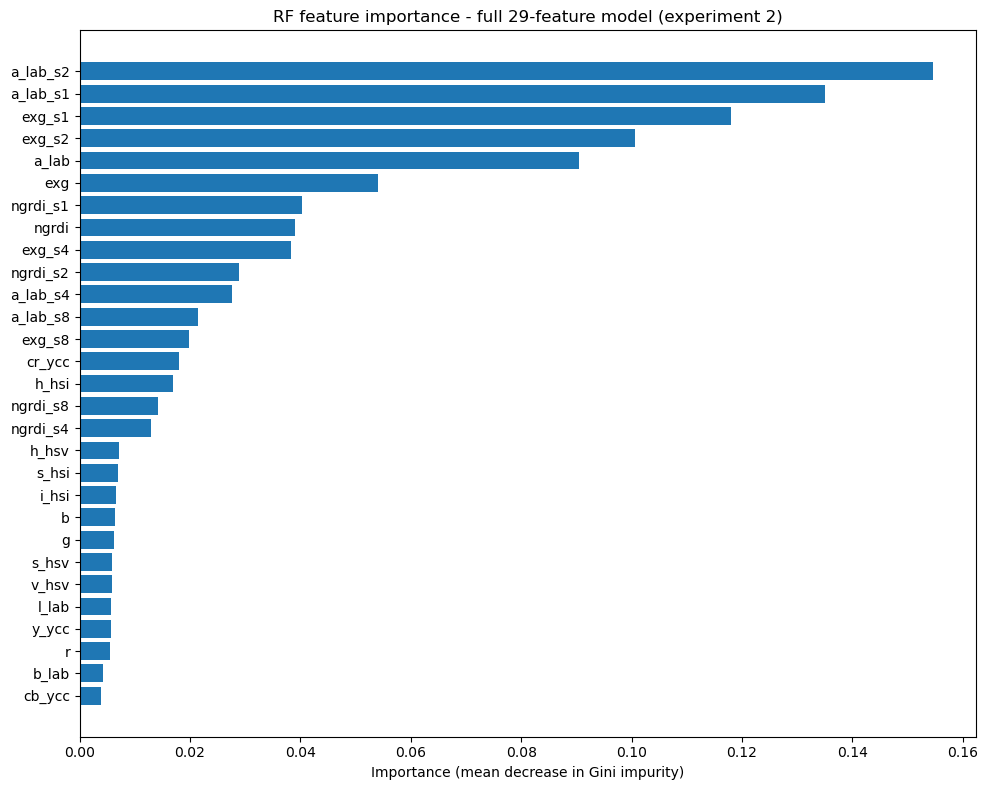


Top 10 features by importance:
   1. a_lab_s2      0.1547
   2. a_lab_s1      0.1350
   3. exg_s1        0.1179
   4. exg_s2        0.1007
   5. a_lab         0.0904
   6. exg           0.0540
   7. ngrdi_s1      0.0403
   8. ngrdi         0.0391
   9. exg_s4        0.0383
  10. ngrdi_s2      0.0289


In [33]:
feature_names = [                                                                                             
  # 17 baseline colour features (order matches compute_pixel_features)
  "r", "g", "b",                                                                                            
  "h_hsv", "s_hsv", "v_hsv",                                                                                
  "l_lab", "a_lab", "b_lab",                                                                                
  "y_ycc", "cr_ycc", "cb_ycc",                                                                              
  "h_hsi", "s_hsi", "i_hsi",                                                                                
  "exg", "ngrdi",                                                                                           
  # 12 multi-scale features                                                                                 
  "a_lab_s1", "a_lab_s2", "a_lab_s4", "a_lab_s8",                                                           
  "exg_s1", "exg_s2", "exg_s4", "exg_s8",                                                                   
  "ngrdi_s1", "ngrdi_s2", "ngrdi_s4", "ngrdi_s8",                                                           
]                                                           
                                                                                                            
importances = rf_v2.feature_importances_                    
order = np.argsort(importances)[::-1]                       
                                                
fig, ax = plt.subplots(figsize=(10, 8))                                                                       
ax.barh(range(len(order)), importances[order][::-1])                                                          
ax.set_yticks(range(len(order)))                                                                              
ax.set_yticklabels([feature_names[i] for i in order[::-1]])                                                   
ax.set_xlabel("Importance (mean decrease in Gini impurity)")                                                  
ax.set_title("RF feature importance - full 29-feature model (experiment 2)")                                  
plt.tight_layout()                                                                                            
plt.show()                                                                                                    
                                          
print("\nTop 10 features by importance:")                                                                     
for rank, i in enumerate(order[:10], 1):                    
  print(f"  {rank:2d}. {feature_names[i]:12s}  {importances[i]:.4f}")  

In [45]:
  log_run(                                                                                                      
      XLSX_PATH,                             
      run_name="final_test_multiscale",                                                                         
      model="RandomForest",                                                                                     
      hparams={                                               
          "n_estimators": 200,                                                                                  
          "max_depth": 20,                                    
          "min_samples_leaf": 1,                                                                                
          "class_weight": "balanced_subsample",
          "features": "17colour+12multiscale(a_lab,ExG,NGRDI@sigma=1,2,4,8)",                                   
      },                                            
      precision=test_summary["precision"],                                                                      
      recall=test_summary["recall"],         
      f1=test_summary["f1"],                                                                                    
      iou=test_summary["iou"],           
      train_time_s=train_time_v2,                                                                               
      eval_time_s=test_summary["time_seconds"],     
      notes="test split (FINAL) - rf_v2 multi-scale, one-shot evaluation",
  )    

logged: final_test_multiscale


## Success / Failure Test Examples

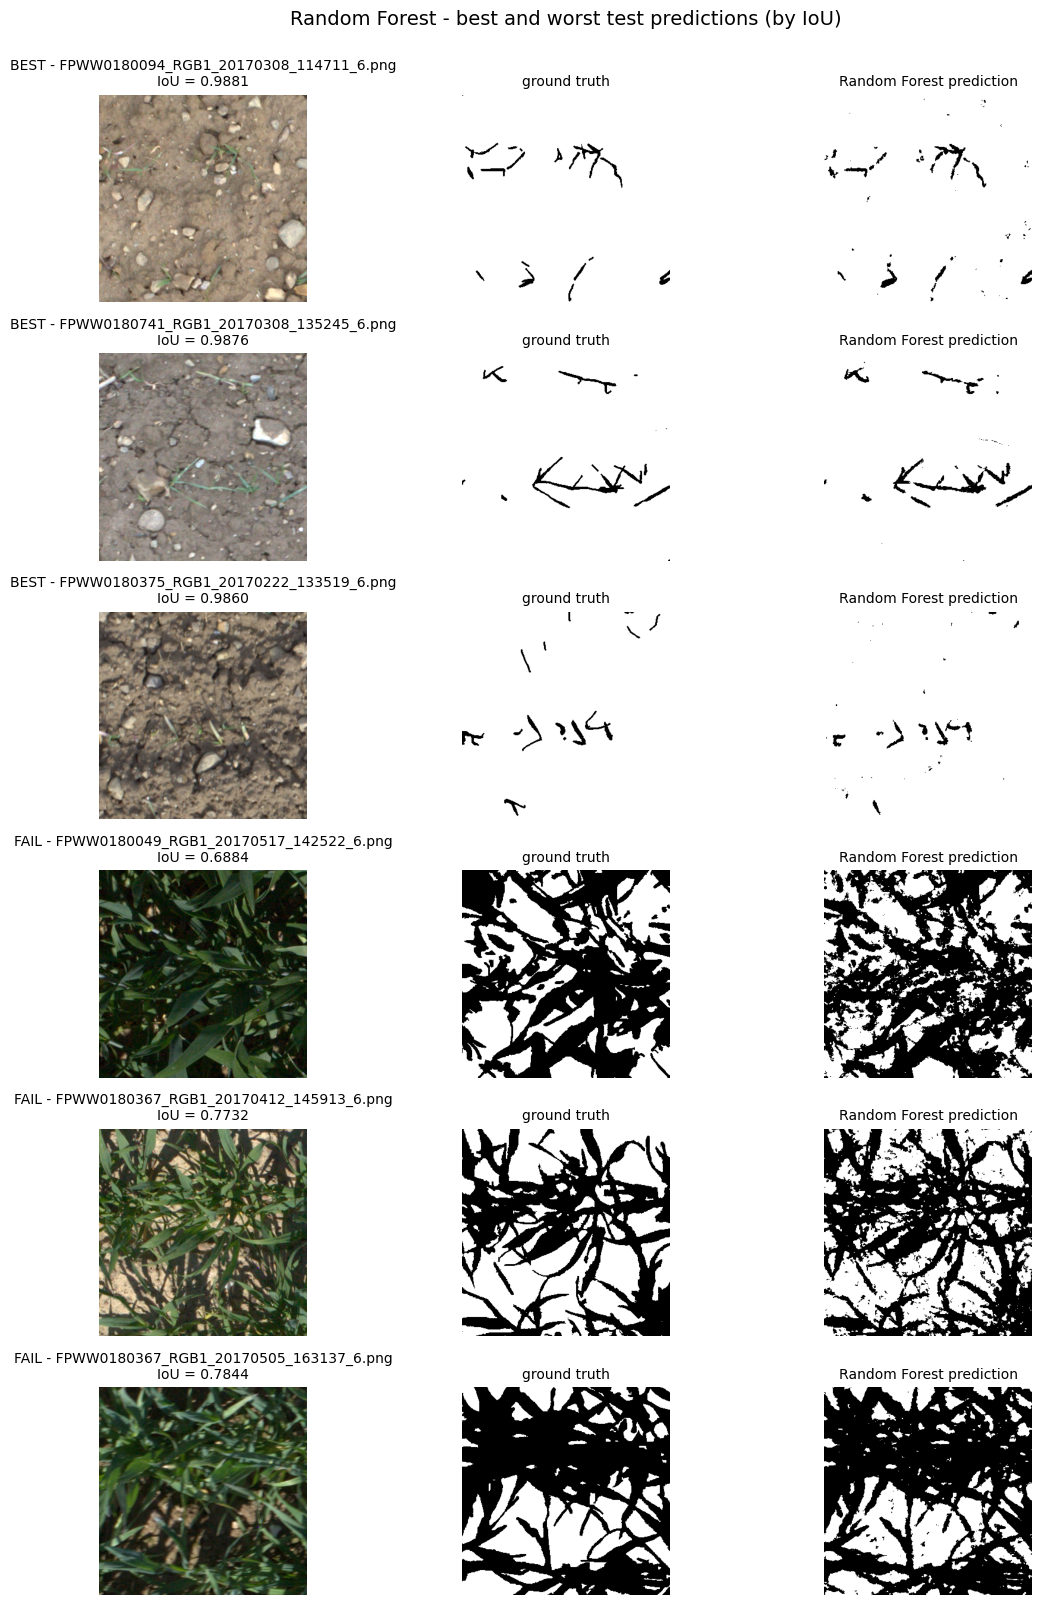

Per-image IoU distribution:
  min:    0.6884
  median: 0.8755
  max:    0.9881
  std:    0.0802


In [46]:
per_image_iou = np.array([
    jaccard_score(gt.flatten(), pred.flatten(), zero_division=0)
    for gt, pred in zip(test_gts, test_preds)
])

order = np.argsort(per_image_iou)
worst_idx = order[:3]
best_idx = order[-3:][::-1]

rows = [("BEST", i) for i in best_idx] + [("FAIL", i) for i in worst_idx]

fig, axes = plt.subplots(6, 3, figsize=(12, 16))

for row, (label, idx) in enumerate(rows):
    img = load_rgb_image(TEST_DIR / test_names[idx])
    gt = test_gts[idx]
    pred = test_preds[idx]
    iou = per_image_iou[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{label} - {test_names[idx]}\nIoU = {iou:.4f}", fontsize=10)                                      
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("ground truth", fontsize=10)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred, cmap="gray")
    axes[row, 2].set_title("Random Forest prediction", fontsize=10)
    axes[row, 2].axis("off")

plt.suptitle("Random Forest - best and worst test predictions (by IoU)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("Per-image IoU distribution:")
print(f"  min:    {per_image_iou.min():.4f}")
print(f"  median: {np.median(per_image_iou):.4f}")
print(f"  max:    {per_image_iou.max():.4f}")
print(f"  std:    {per_image_iou.std():.4f}")